In [3]:
# keep a record of the heat blob dynamics 
# and output the final classification of each blob as human or residual heat for each frame at the end
# also, keep a record of the postures
# output the final classification of posture in each image seq
    # -1: unknown or unlabeled; 
    # 0: absence; 
    # 1: presence, unclassified; 
    # 2: standing; 
    # 3: sitting by bed; 
    # 4: sitting on bed; 
    # 5: lying w/o cover; 
    # 6: lying with cover
import sys
from pathlib import Path
sys.path.insert(0, "/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/src")

import yaml
import json   
from organizer_module.postprocessor import PostProcessor
from dataset.dataset import ThermalDataset
from heatsource_detection_module.extract import HeatSourceDetector
from posture_detection_module.CNN_model import SimpleIRA_CNN
from posture_detection_module.utils import remap_labels_simple, inverse_remap_labels_simple, label_to_text_simple, ThermalInvariantPreprocessor
from organizer_module.track_kalman import Tracker
from data_visualization_module.plot import DataVisualizer
import torch
import cv2
from tqdm import tqdm
import numpy as np

dv = DataVisualizer()
data_name = "case_study_hall1"



In [4]:

def visualize_frame(ira, blobs, posture_label, index, waittime = 1):
    # visualize the blobs and posture label on the ira_highres image, and save the image to disk
    thermal_prepared = dv._prepare_thermal_for_colormap(ira)
    ira_color = cv2.applyColorMap(thermal_prepared, cv2.COLORMAP_JET)
    # rescale the image to 5 times
    scale_factor = 10
    ira_color = cv2.resize(ira_color, (ira_color.shape[1] * scale_factor, ira_color.shape[0] * scale_factor), interpolation=cv2.INTER_NEAREST)

    corr = 0

    # plot the blobs on the image, use green circle for human and yellow circle for residual heat
    for blob in blobs:
        if blob.mean_temp is None or blob.centroid is None:
            continue
        color = (0, 255, 0) if blob.is_residual == False else (0, 255, 255)
        # cv2.circle(ira_color, (int(blob.centroid[1]), int(blob.centroid[0])), 10, color, 2)
        # mark the blob id on the image
        x_min, y_min, x_max, y_max = blob.get_state()
        cv2.putText(ira_color, f'ID: {blob.id_fixed}', (int(x_min*scale_factor), int(y_min*scale_factor)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        cv2.putText(ira_color, f'corr: {blob.corr:.1f}', (int(x_min*scale_factor), int((y_min+15)*scale_factor)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        # draw bbox
        corr = blob.corr
        x_min = int(x_min * scale_factor)
        y_min = int(y_min * scale_factor)
        x_max = int(x_max * scale_factor)
        y_max = int(y_max * scale_factor)
        cv2.rectangle(ira_color, (x_min, y_min), (x_max, y_max), color, 2)

    cv2.putText(ira_color, f'Frame: {index}| Posture: {posture_label}|Corr: {corr:.3f}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    cv2.imshow('ira', ira_color)
    key = cv2.waitKey(waittime)
    if key == ord('q'):
        cv2.destroyAllWindows()
        sys.exit(0)


In [5]:
 
# Run entire pipeline
def test_postprocessor():
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    # 1. load the dataset
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module
    tracker = Tracker()
    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()
    
    gt_result_lst = []

    print("dataset length: ", len(dataset))

    # 3. loop through each fraome
    for idx in range(0, len(dataset), 1):
        # if idx == 8720:
        #     waittime = 0
        label = dataset.annotations_expanded[idx]
        # if label == -1:
        #      continue
        gt_result_lst.append(label)
        ira_highres = dataset.get_ira_highres(idx)
        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        # mask_processed = heat_detector.process_frame_mask(ira_highres, min_size=100)
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)
        #   3.2. detect presence with kalman tracker
        tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
        postprocessor.get_blobs(tracker.blobs, idx)
        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        hasHuman = False
        for blob in tracker.blobs:
            if blob.is_residual == False: # if it is classified as human
                hasHuman = True
        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            postprocessor.get_posture(0, idx)
        
    
    print("DEBUG: posture records: ", len(postprocessor.posture_records), len(gt_result_lst))

    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json', 'w') as f:
        json.dump({'results': results, 'gt_result_lst': gt_result_lst}, f, indent=4)

    # 4. postprocess
    #   4.1. postprocess presence, make a list of presence data
    # postprocessor.postprocess_presence()

    #   4.2. postprocess postures, make a list of posture data.
    # postprocessor.postprocess_posture()

    # 5. compare the smoothed posture classification result with the ground truth label, and visualize the comparison
    # 5. visualize: plot the posture classification result for each frame, and compare with the ground truth label
    #   5.1. visualize the presence detection result for each frame, and compare with the ground truth label
    #   5.2. visualize the blob classification result for each frame, and compare with the ground truth label
   


def confusion_matrix_draw(results, gt_result_lst):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    y_true = gt_result_lst
    y_pred = [1 if r[1] == 'HUMAN' else 0 for r in results]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Human'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix for Posture Classification")
    plt.show()


In [9]:

# run the entire pipeline on one data entry
def test_inference(data_name=data_name, model_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'):
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    
    # 1. load the dataset ===============================================
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    print(f"dataset {data_name}; length:", len(dataset))


    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module
    tracker = Tracker()
    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()

    import matplotlib.pyplot as plt
    from tqdm import tqdm
    

    # 3. loop through each fraome ========================================
    #   3.1. prepare the ground truth label list
    gt_result_lst = []
    waittime = 1
    visualization = True
    for idx in tqdm(range(0, len(dataset), 1)):
        # gt
        label = dataset.annotations_expanded[idx]
        gt_result_lst.append(label)

        # data
        ira_highres = dataset.get_ira_highres(idx)
        # make pixels less than 17 deg be 17 deg
        ira_highres[ira_highres < 18] = 18

        # plt.imshow(ira_highres)
        # plt.show()

        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

        #   3.2. detect presence with kalman tracker
        tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
        postprocessor.get_blobs(tracker.blobs, idx)

        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        hasHuman = False
        for blob in tracker.blobs:
            if blob.is_residual == False: # if it is classified as human
                hasHuman = True

        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            postprocessor.get_posture(0, idx)

        # visualize the result for this frame
        if visualization:
            visualize_frame(ira_highres, tracker.blobs, posture_str, idx, waittime)
    
    # 4. save the results to /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_nopostprocess_exp.json', 'w') as f:
        json.dump({'results': postprocessor.posture_records, 'gt_result_lst': gt_result_lst}, f, indent=4)

    # draw the confusion matrix for posture classificatino result
    # confusion_matrix_draw(postprocessor.posture_records, gt_result_lst)

def confusion_matrix_draw(results, gt_result_lst):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    y_true = gt_result_lst
    y_pred = [1 if r[1] == 'HUMAN' else 0 for r in results]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Human'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix for Posture Classification")
    plt.show()

# results = postprocessor.posture_records
# # write results and gt_result_lst to a json file for later analysis
# with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json', 'w') as f:
#     json.dump({'results': results, 'gt_result_lst': gt_result_lst}, f, indent=4)

def pipeline_gridsearch():
    # load yaml content from /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/config/exp_setup.yaml
    with open('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/config/exp_setup.yaml', 'r') as f:
        config = yaml.safe_load(f)
        train_all = config['train_all'][:3]
    TEMP_DECREASE_THRESH = [-0.9, -0.92, -0.95]
    K_THRESH = [0.003, 0.004, 0.005]

    for temp_thresh in TEMP_DECREASE_THRESH:
        for k_thresh in K_THRESH:
            pred = []
            gt = []
            print(f"Testing with TEMP_DECREASE_THRESH: {temp_thresh}, K_THRESH: {k_thresh}")
            for folder in train_all:
                gt_result_lst, pred_res_lst = pipeline_gridsearch(folder)
                pred.extend(pred_res_lst)
                gt.extend(gt_result_lst)
                print("accuracy: ", sum([1 if p == 1 and g == 1 else 0 for p, g in zip(pred_res_lst, gt_result_lst)]) / len(gt_result_lst))
                print("present predicted as absent: ", sum([1 if p == 0 and g == 1 else 0 for p, g in zip(pred_res_lst, gt_result_lst)]) / len(gt_result_lst))
                plt.plot(pred_res_lst, alpha = 0.5, label = "pred")
                plt.plot(gt_result_lst, alpha = 0.5, label = "GT")
                plt.legend()
                plt.show()
                print("absent predicted as present: ", sum([1 if p == 1 and g == 0 else 0 for p, g in zip(pred_res_lst, gt_result_lst)]) / len(gt_result_lst)) 
            print("===summary: present predicted as absent: ", sum([1 if p == 0 and g == 1 else 0 for p, g in zip(pred, gt)]) / len(gt))
            print("===summary: absent predicted as present: ", sum([1 if p == 1 and g == 0 else 0 for p, g in zip(pred, gt)]) / len(gt))
            print("=== summary: accuracy: ", sum([1 if p == 1 and g == 1 else 0 for p, g in zip(pred, gt)]) / len(gt)) 


def vis_json_results(data_name = data_name, suffix = "nopostprocess_exp"):
    import matplotlib.pyplot as plt
    from organizer_module.postprocessor import PostProcessor
    import numpy as np

    # load from json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_{suffix}.json', 'r') as f:
        data = json.load(f)
        results = data['results']
        gt_result_lst = data['gt_result_lst']

    print("DEBUG: results len: ", len(results))
    print("DEBUG: gt_result_lst len: ", len(gt_result_lst))

    # Apply Markov smoothing to the results
    # pp = PostProcessor()
    # pp.posture_records = results.copy()
    # # pp._markov_smoothing()
    # smoothed_results = pp.posture_records

    smoothed_results = results.copy()

    def compute_accuracy(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g == 1:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            elif p == g:
                    correct += 1
            total += 1
        return correct / total

    accuracy_before = compute_accuracy(results, gt_result_lst)
    accuracy_after = compute_accuracy(smoothed_results, gt_result_lst)
    print("accuracy before smoothing: ", accuracy_before)

    plt.plot(smoothed_results, alpha = 0.5)
    # plt.plot(results, alpha = 0.5)
    plt.plot(gt_result_lst, alpha = 0.5)
    plt.show()
    # print(f"Accuracy before smoothing: {accuracy_before:.4f}")
    # print(f"Accuracy after smoothing: {accuracy_after:.4f}")

    # count the accuracy
    # when gt_results_lst is -1, we regard it as 0
    # when gt_results_lst is 1, it can match all the presence labels (2, 3, 4, 5, 6)
    # compute the accuracy
    correct = 0
    total = 0
    for i in range(len(gt_result_lst)):
        gt = gt_result_lst[i]
        pred = results[i]
        if gt == -1:
            gt = 0
        if gt == 1:
            if pred in [2, 3, 4, 5, 6]:
                correct += 1
        else:
            if pred == gt:
                correct += 1
        total += 1
    accuracy = correct / total
    print(f"Accuracy: {accuracy:.4f}")


    # plot confusion matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    # presence classification confusion matrix
    y_true = [1 if r in [2, 3, 4, 5, 6] else 0 for r in gt_result_lst]
    y_pred = [1 if r in [2, 3, 4, 5, 6] else 0 for r in results]
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix for Presence Classification:", cm)

    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Human'])
    # disp.plot(cmap=plt.cm.Blues)
    # plt.title("Confusion Matrix for Presence Classification (Binary)")
    # plt.show()

    # plot posture classification confusion matrix
    # remove ambiguous labels in gt_result_lst and results
    y_true = [r for r in gt_result_lst if r != -1 and r != 1]
    y_pred = [results[i] for i in range(len(results)) if gt_result_lst[i] != -1 and gt_result_lst[i] != 1]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 2, 3, 4, 5, 6])
    print("Confusion Matrix for Posture Classification (Detailed):", cm)

    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Standing', 'Sitting by Bed', 'Sitting on Bed', 'Lying w/o Cover', 'Lying with Cover'])
    # disp.plot(cmap=plt.cm.Blues)
    # # rotate x label by 45 degree
    # plt.xticks(rotation=45)
    # plt.title("Confusion Matrix for Posture Classification (Detailed)")
    # plt.show()
def vis_results(data_name = "office0_4"):
    # visualize the results in /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_nopostprocess_exp.json
    # data_name = "home01"
    vis_json_results(data_name)

def test_users_inenv():
    # test the model across different users
    model_path = "/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_all_full.pth"
    test_env = ['office0_4', 'home01', 'home2', 'home31']
    test_env = ['office0_4']

    # load the model
    for e in test_env:
        test_inference(model_path = model_path, data_name = e)

def test_users_crossenv():
    # test the model across different users and environments
    test_env = ['hall5', 'office1_0', 'office2_0']
    test_env_ids = ['env0', 'env5', 'env6']
    for env, env_id in zip(test_env, test_env_ids):
        model_path = f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_{env_id}.pth"
        test_inference(model_path = model_path, data_name = env)




dataset office0_2; length: 15525


 20%|█▉        | 3052/15525 [01:04<04:12, 49.35it/s]

Human left the bed! Residual heat detected. Frame index:  3044


 95%|█████████▍| 14731/15525 [05:05<00:17, 44.81it/s]

Human left the bed! Residual heat detected. Frame index:  14725


100%|██████████| 15525/15525 [05:19<00:00, 48.56it/s]


DEBUG: results len:  15525
DEBUG: gt_result_lst len:  15525
accuracy before smoothing:  0.9953646275380297


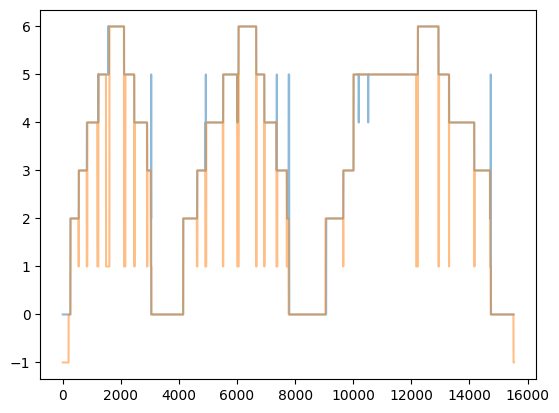

Accuracy: 0.9954
Confusion Matrix for Presence Classification: [[ 3398   647]
 [   23 11457]]
Confusion Matrix for Posture Classification (Detailed): [[3175    3    0    0   27    0]
 [  23 1365    0    0    0    0]
 [   0    0 1861    0    0    0]
 [   0    0    0 2611    1    0]
 [   0    0    0    2 3811    0]
 [   0    0    0    0    0 1806]]


In [ ]:
# test_results()
# test_postprocessor()
if __name__ == "__main__":
    # office0_4: 0.9919028340080972
    # hall5: 0.9850
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0
    env = "office0_2"
    test_inference(env)
    vis_results(env)
    # pipeline_gridsearch()
    # test_users_inenv()
    # test_users_crossenv()